In [1]:
from model_ranking import (
    load_h5,
    get_roi_slice,
    get_random_colors,
)
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from pytorch3dunet.augment.transforms import Relabel

INFO: P [MainThread] 2025-10-07 12:34:13,324 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
p_gt_paths = [
    "/scratch/talks/data/PNAS/test/24hrs_plant18_trim-acylYFP.h5",
    "/scratch/talks/data/PNAS/test/36hrs_plant18_trim-acylYFP.h5",
]
label_key = "label"
raw_key = "raw"

p_gt = load_h5(p_gt_paths[0], label_key)
p_raw = load_h5(p_gt_paths[0], raw_key)
print(p_gt.shape, p_raw.shape)

(174, 512, 512) (174, 512, 512)


# Ov_model_UNet1

In [3]:
pred_path_NA = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/Ovules_to_PNAS_gap/consistency/P_full/ov_model_UNet1/norm_50_950/none/predictions/24hrs_plant18_trim-acylYFP_predictions.h5"
preds_NA = load_h5(pred_path_NA, "predictions")
segs_NA = load_h5(pred_path_NA, "segmentation")
MAP_score_NA = load_h5(pred_path_NA, "MAP_05_095")
patch_indexes = load_h5(pred_path_NA, "patch_index")
print(preds_NA.shape, MAP_score_NA.shape)

(696, 1, 1, 256, 256) (696,)


In [4]:
print(np.median(MAP_score_NA))

0.5236306


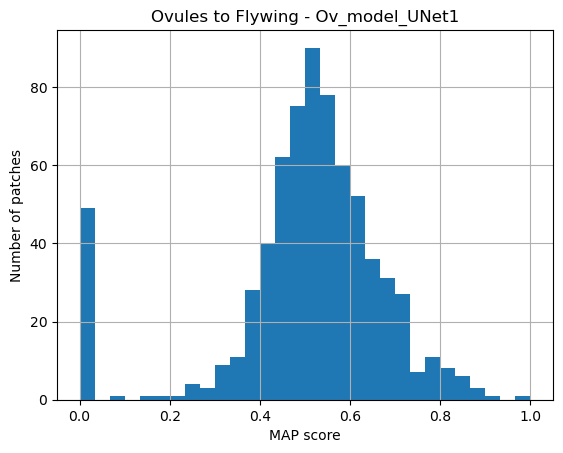

In [5]:
plt.hist(MAP_score_NA, bins=30)
plt.xlabel("MAP score")
plt.ylabel("Number of patches")
plt.title("Ovules to Flywing - Ov_model_UNet1")
plt.grid()
plt.show()

In [6]:
ids_sub_04 = np.where(MAP_score_NA < 0.4)[0]
print(len(ids_sub_04))

108


In [9]:
ids_abv_05 = np.where(MAP_score_NA > 0.5)[0]
print(len(ids_abv_05))

411


6


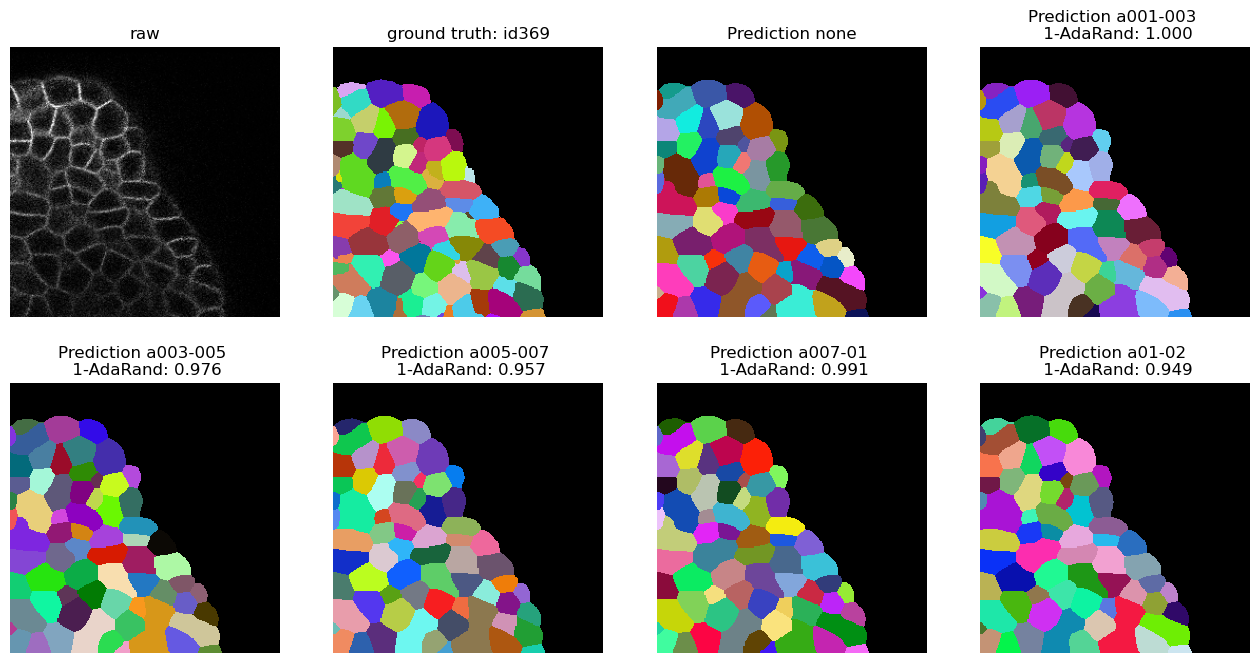

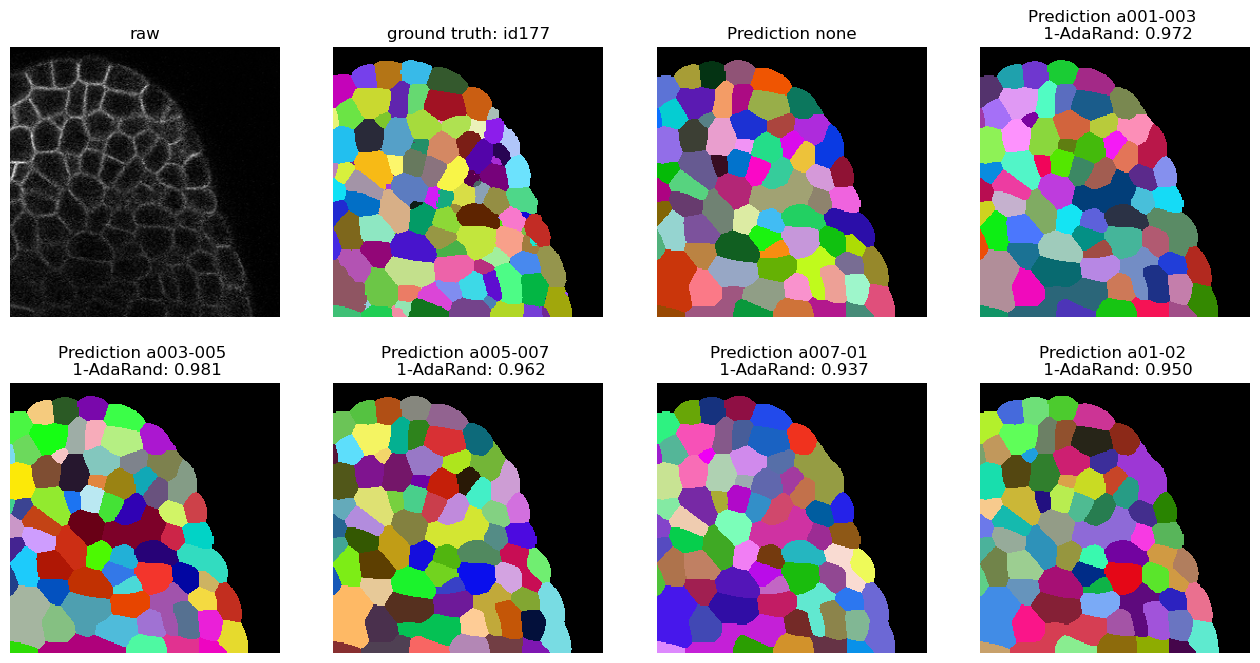

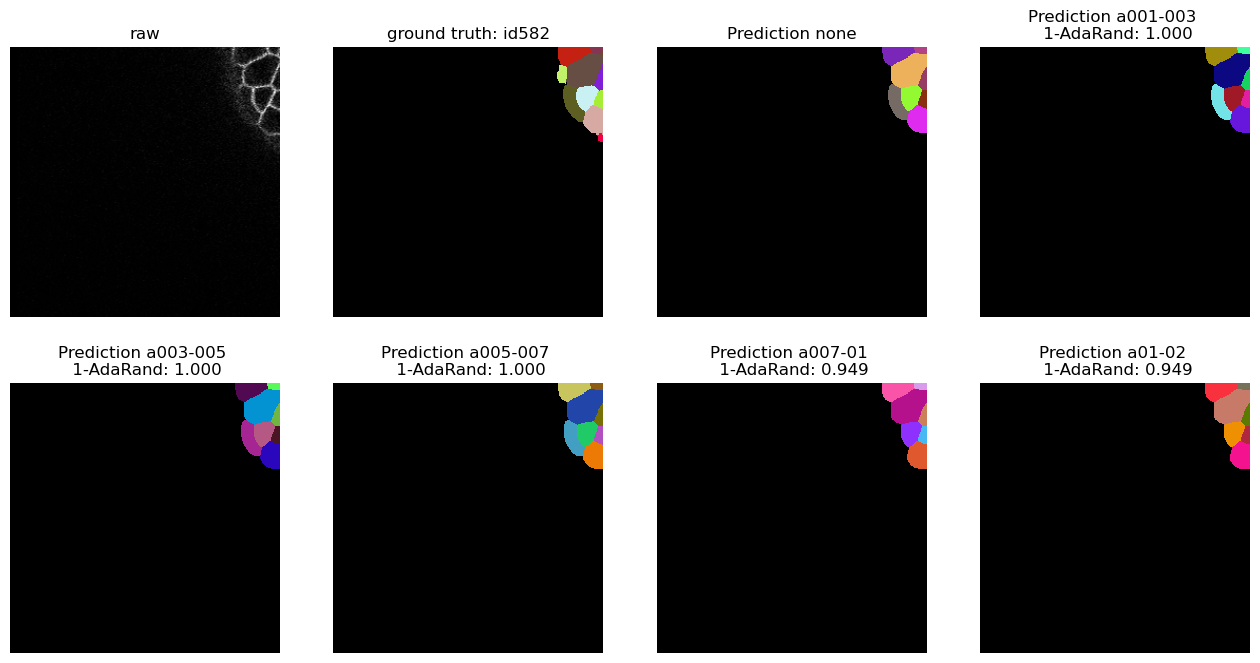

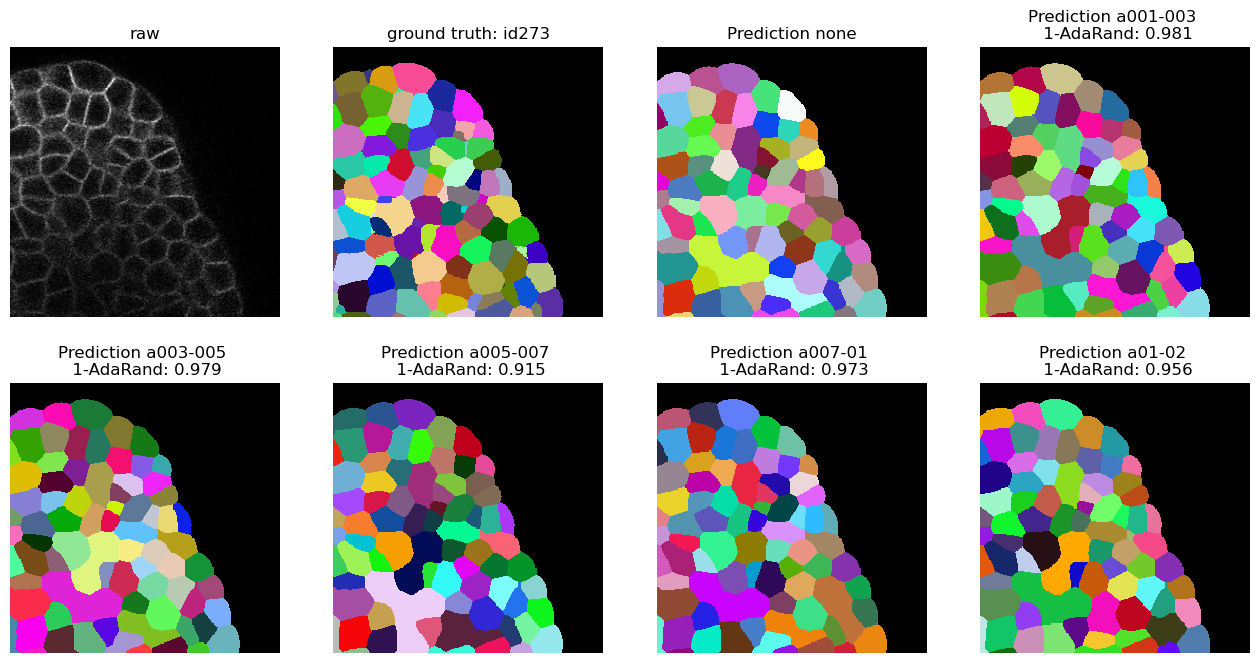

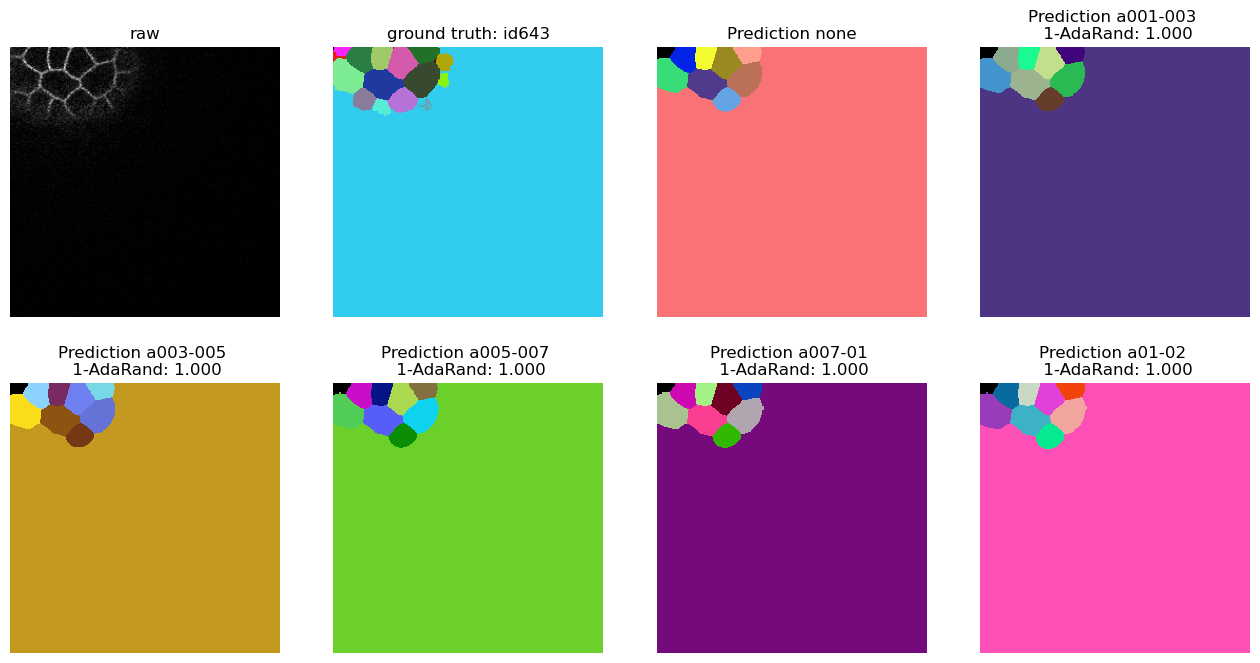

In [12]:
num_samples = 5
selected_augs = ["none", "a001-003", 'a003-005', 'a005-007', 'a007-01', 'a01-02']
rng = np.random.default_rng(42)
rng.shuffle(ids_abv_05)
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/Ovules_to_PNAS_gap/consistency/P_full/ov_model_UNet1/norm_50_950"
paths = list(Path(base_path).rglob("**/predictions/24hrs_plant18_trim-acylYFP_predictions.h5"))
print(len(paths))

for i in ids_abv_05[:num_samples]:
    patch_roi = get_roi_slice(patch_indexes[i])
    raw = p_raw[patch_roi].squeeze()
    label = p_gt[patch_roi].squeeze()
    label = Relabel(append_original = True, ignore_label=-1)(label)
    _, axs = plt.subplots(2,4, figsize=(16,8))
    axs = axs.flatten()
    axs[0].imshow(raw, cmap='gray')
    axs[0].set_title("raw")
    axs[0].axis('off')
    axs[1].imshow(label[0], cmap=get_random_colors(label[0]), interpolation='nearest')
    axs[1].set_title(f"ground truth: id{i}")
    axs[1].axis('off')
    # axs[2].imshow(load_h5(pred_path_NA, "segmentation", select_index=i).squeeze(), cmap='magma')
    # axs[2].set_title(f"Segmentation NA \n MAP: {MAP_score_NA[i]:.3f}")
    # axs[2].axis('off')
    for j, path in enumerate(paths):
        assert selected_augs[j] in str(path)
        preds_temp = load_h5(path, "segmentation", select_index=i)
        axs[2+j].imshow(preds_temp.squeeze(), cmap=get_random_colors(preds_temp), interpolation='nearest')
        if "none" not in str(path):
            AdaRand_score = 1 - load_h5(path, "AdaRandError_consis", select_index=i)[0]
            axs[2+j].set_title(f"Prediction {selected_augs[j]} \n 1-AdaRand: {AdaRand_score:.3f}")
        else:
            axs[2+j].set_title(f"Prediction {selected_augs[j]}")
        axs[2+j].axis('off')
    plt.show()

# p_model_UNet1

In [14]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/PNAS_to_Ovules_gap/consistency/P_full/p_model_UNet1/norm_50_950"
paths = list(Path(base_path).rglob("**/predictions/N_294_final_crop_ds2_predictions.h5"))
print(len(paths))

6


/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/PNAS_to_Ovules_gap/consistency/P_full/p_model_UNet1/norm_50_950/none/predictions/N_294_final_crop_ds2_predictions.h5


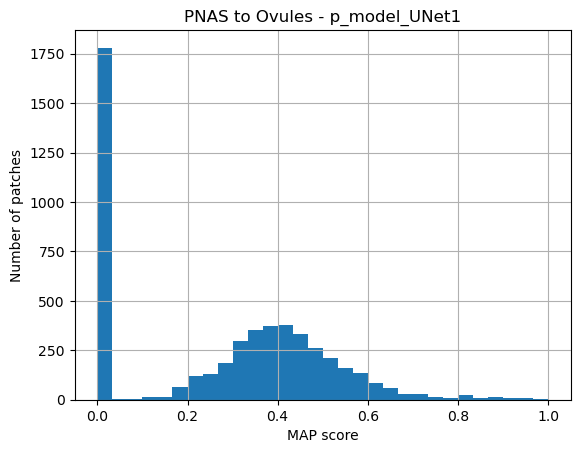

In [18]:
print(paths[0])
MAP_score_NA = load_h5(paths[0], "MAP_05_095")
ids = np.where(np.isnan(MAP_score_NA))[0]
MAP_score_NA[ids] = 0
plt.hist(MAP_score_NA, bins=30)
plt.xlabel("MAP score")
plt.ylabel("Number of patches")
plt.title("PNAS to Ovules - p_model_UNet1")
plt.grid()
plt.show()

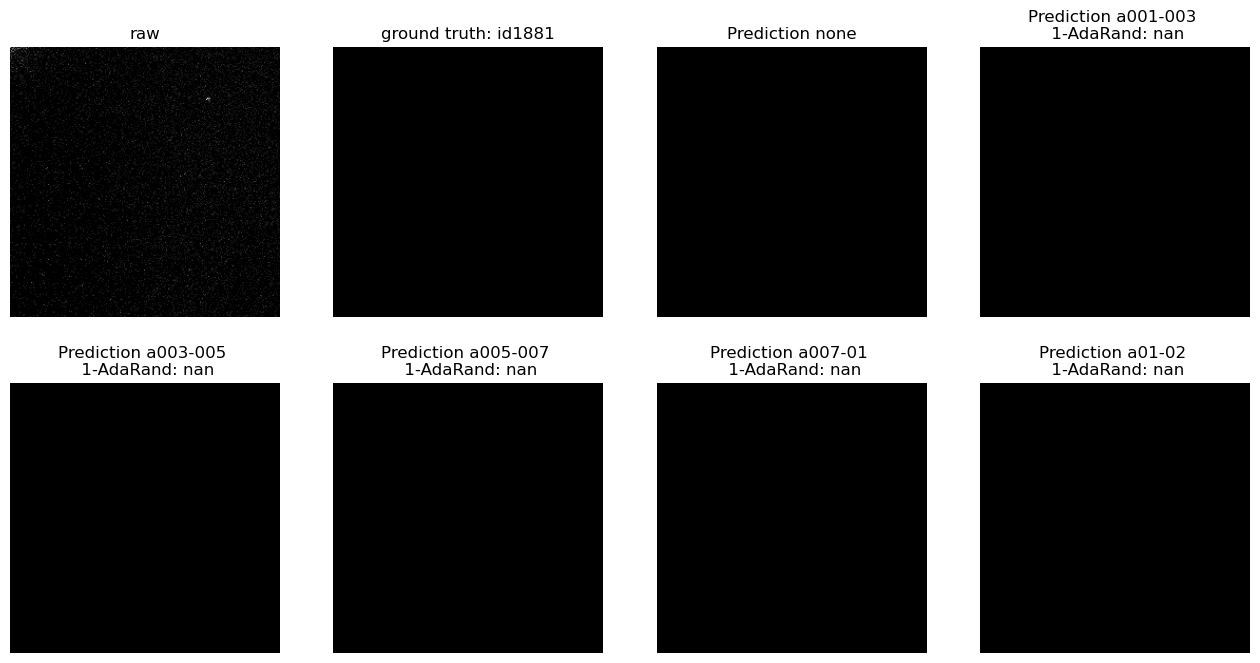

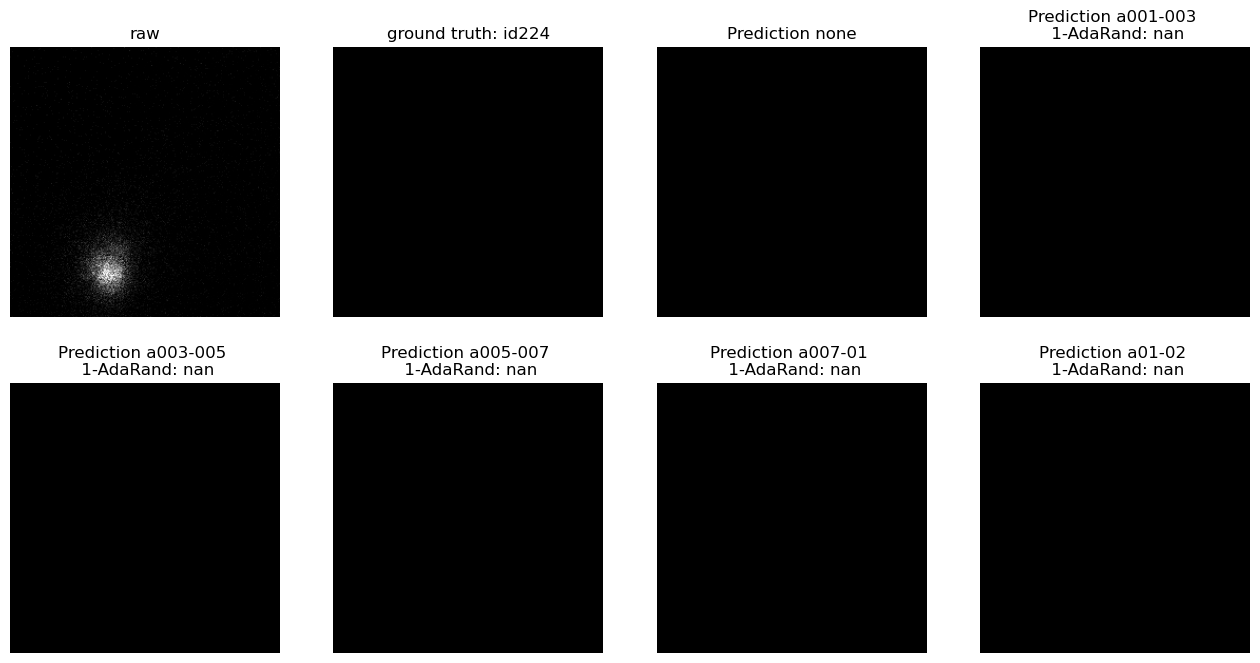

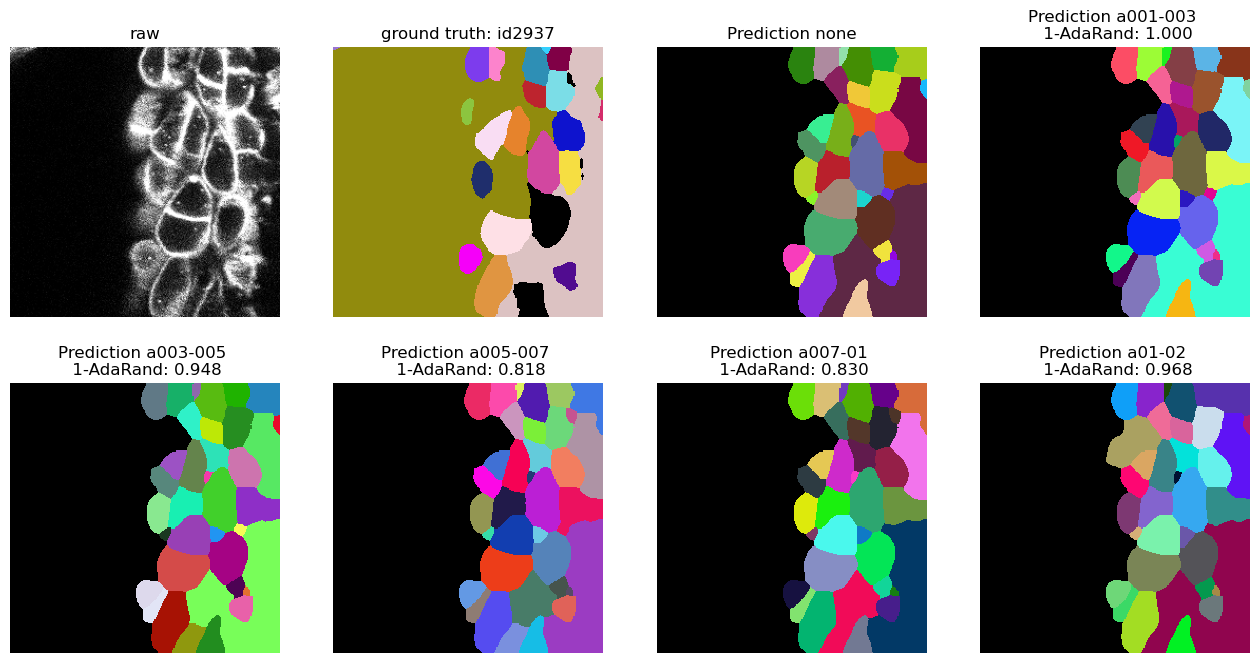

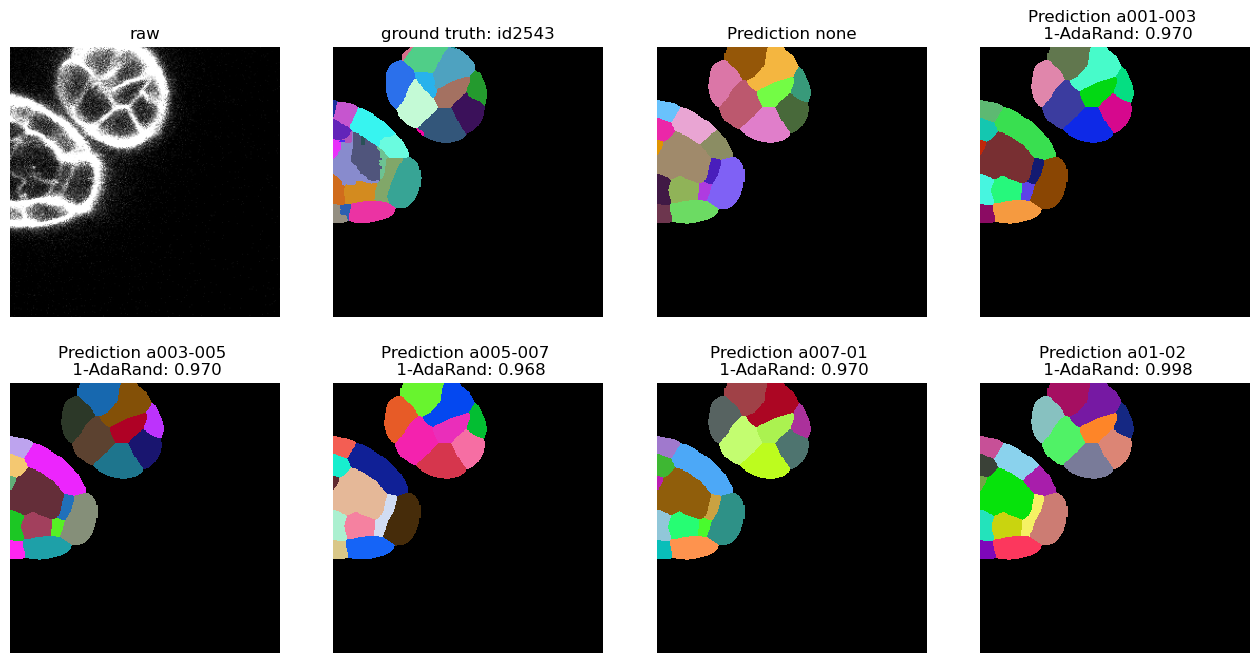

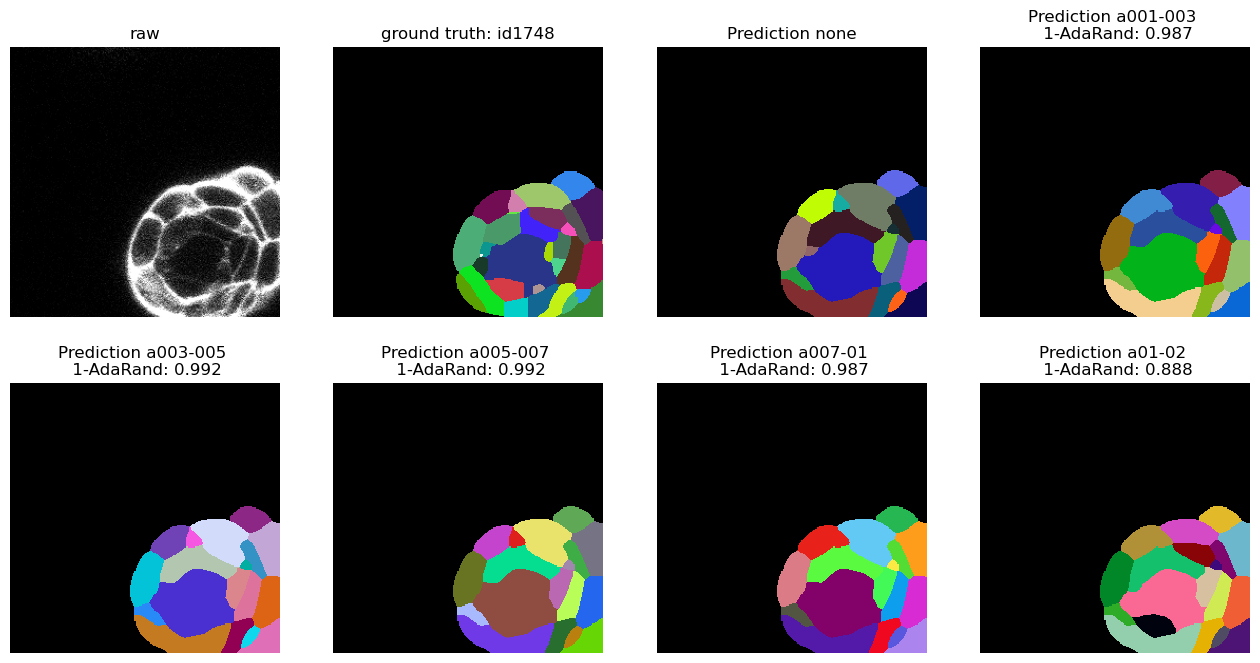

In [19]:
num_samples = 5
selected_augs = ["none", "a001-003", 'a003-005', 'a005-007', 'a007-01', 'a01-02']
rng = np.random.default_rng(42)
rng.shuffle(ids_sub_04)

for i in ids_sub_04[:num_samples]:
    patch_roi = get_roi_slice(patch_indexes[i])
    raw = fw_raw[patch_roi].squeeze()
    label = fw_gt[patch_roi].squeeze()
    label = Relabel(append_original = True, ignore_label=-1)(label)
    _, axs = plt.subplots(2,4, figsize=(16,8))
    axs = axs.flatten()
    axs[0].imshow(raw, cmap='gray')
    axs[0].set_title("raw")
    axs[0].axis('off')
    axs[1].imshow(label[0], cmap=get_random_colors(label[0]), interpolation='nearest')
    axs[1].set_title(f"ground truth: id{i}")
    axs[1].axis('off')
    # axs[2].imshow(load_h5(pred_path_NA, "segmentation", select_index=i).squeeze(), cmap='magma')
    # axs[2].set_title(f"Segmentation NA \n MAP: {MAP_score_NA[i]:.3f}")
    # axs[2].axis('off')
    for j, path in enumerate(paths):
        assert selected_augs[j] in str(path)
        preds_temp = load_h5(path, "segmentation", select_index=i)
        axs[2+j].imshow(preds_temp.squeeze(), cmap=get_random_colors(preds_temp), interpolation='nearest')
        if "none" not in str(path):
            AdaRand_score = 1 - load_h5(path, "AdaRandError_consis", select_index=i)[0]
            axs[2+j].set_title(f"Prediction {selected_augs[j]} \n 1-AdaRand: {AdaRand_score:.3f}")
        else:
            axs[2+j].set_title(f"Prediction {selected_augs[j]}")
        axs[2+j].axis('off')
    plt.show()

# fw_model_Unetr2

In [12]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P_full/fw_model_Unetr2/norm_50_950"
paths = list(Path(base_path).rglob("**/predictions/N_294_final_crop_ds2_predictions.h5"))
print(len(paths))

6


In [18]:
ids_sub_04 = np.where(MAP_score_NA < 0.4)[0]
print(len(ids_sub_04))

144


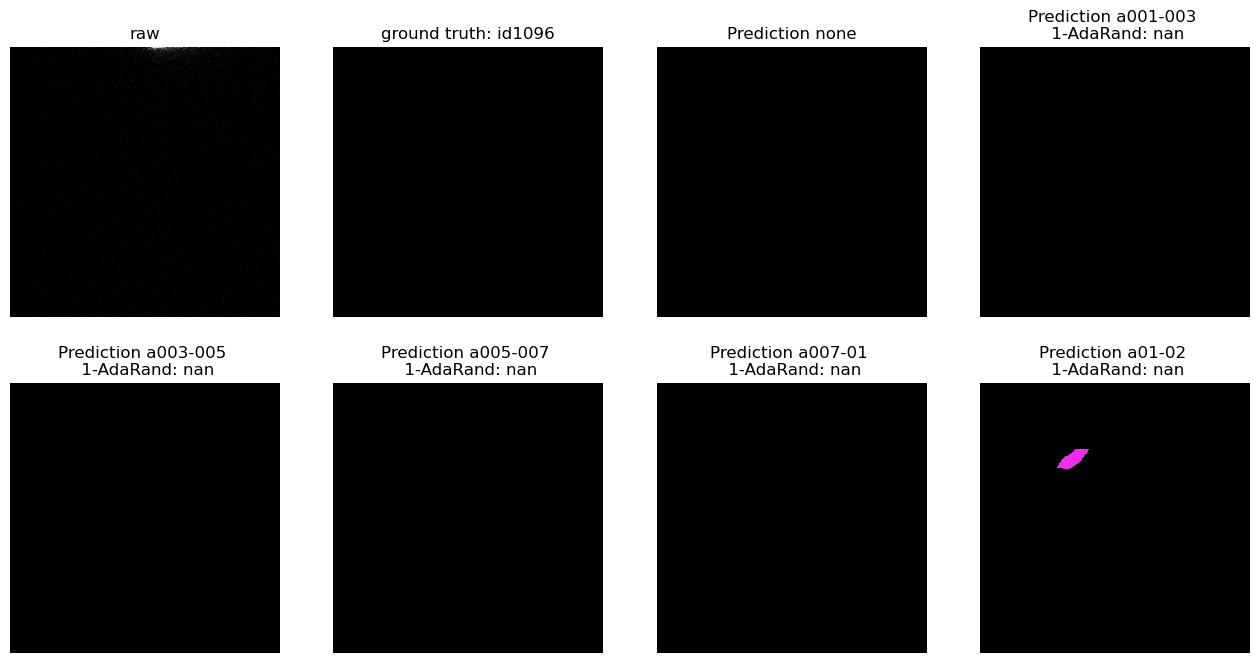

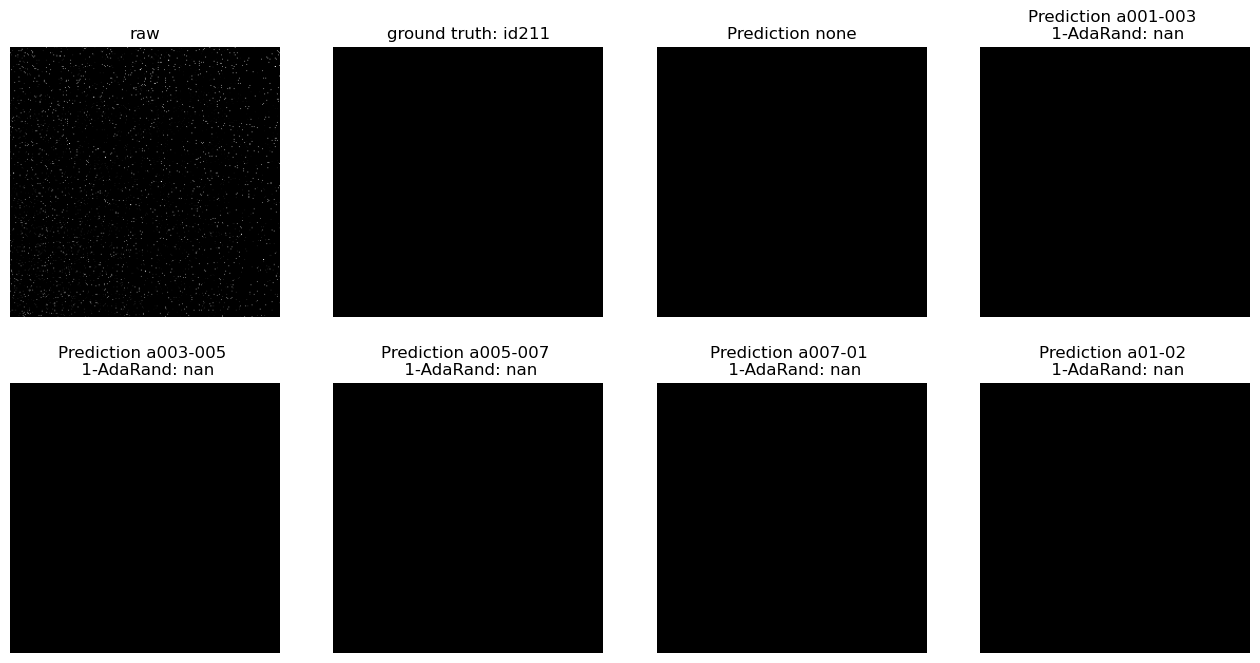

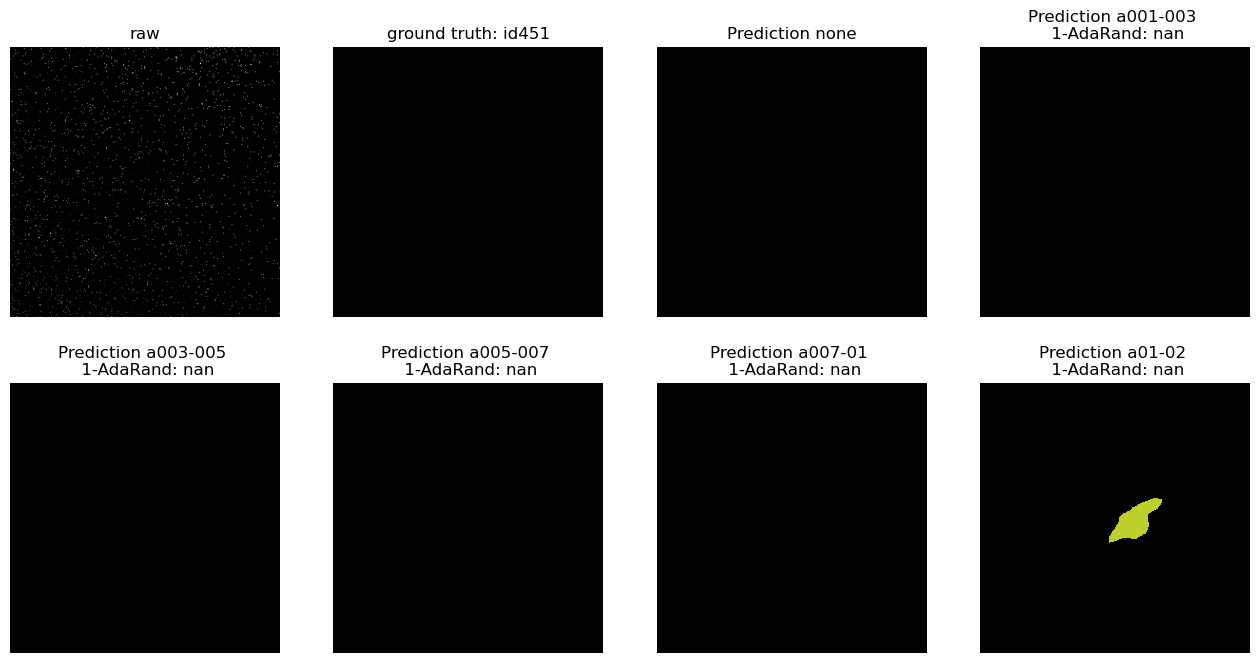

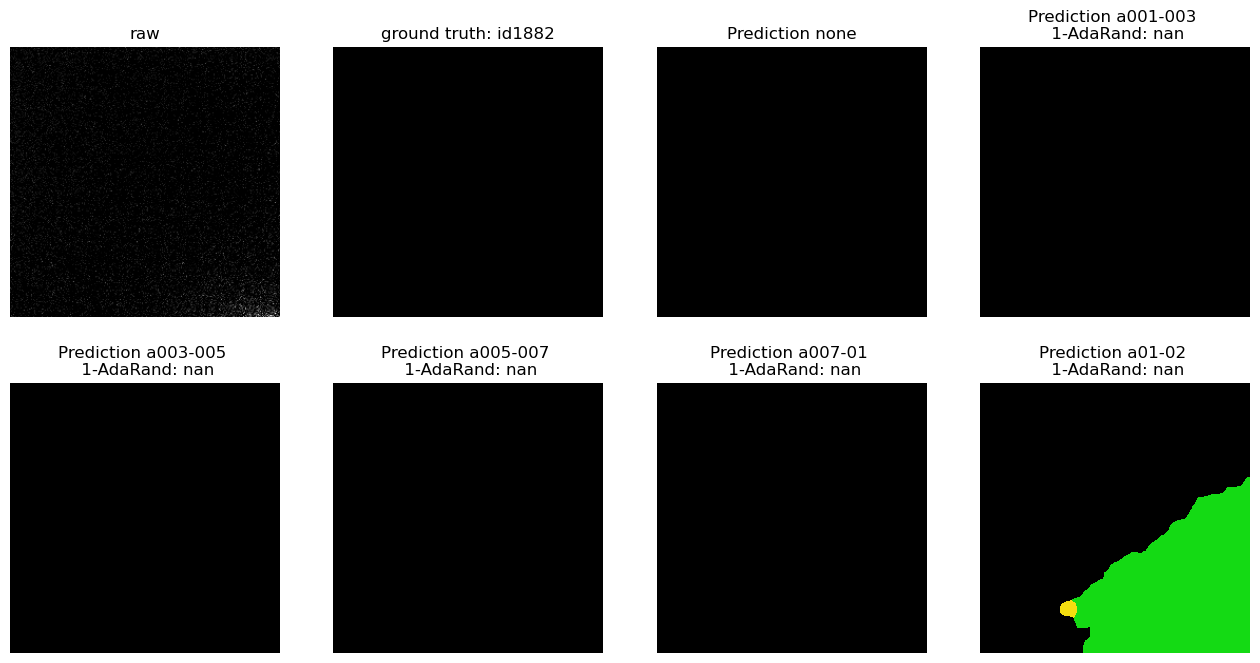

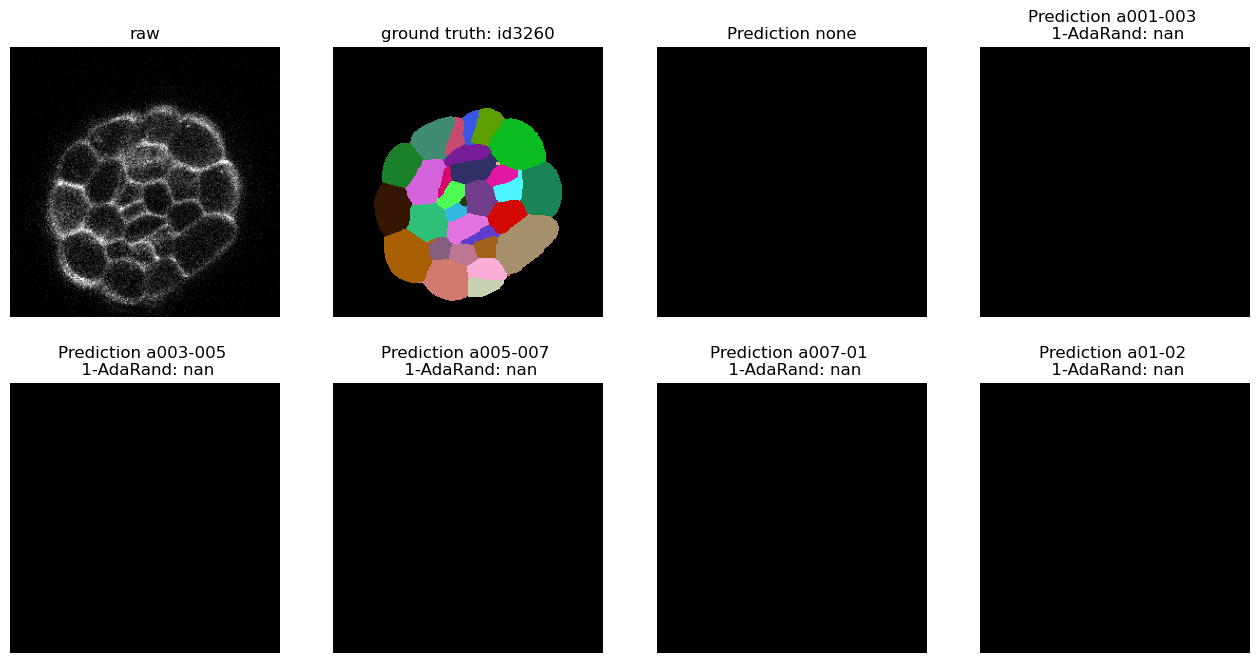

In [13]:
num_samples = 5
selected_augs = ["none", "a001-003", 'a003-005', 'a005-007', 'a007-01', 'a01-02']
rng = np.random.default_rng(42)
rng.shuffle(ids_sub_04)

for i in ids_sub_04[:num_samples]:
    patch_roi = get_roi_slice(patch_indexes[i])
    raw = fw_raw[patch_roi].squeeze()
    label = fw_gt[patch_roi].squeeze()
    label = Relabel(append_original = True, ignore_label=-1)(label)
    _, axs = plt.subplots(2,4, figsize=(16,8))
    axs = axs.flatten()
    axs[0].imshow(raw, cmap='gray')
    axs[0].set_title("raw")
    axs[0].axis('off')
    axs[1].imshow(label[0], cmap=get_random_colors(label[0]), interpolation='nearest')
    axs[1].set_title(f"ground truth: id{i}")
    axs[1].axis('off')
    # axs[2].imshow(load_h5(pred_path_NA, "segmentation", select_index=i).squeeze(), cmap='magma')
    # axs[2].set_title(f"Segmentation NA \n MAP: {MAP_score_NA[i]:.3f}")
    # axs[2].axis('off')
    for j, path in enumerate(paths):
        assert selected_augs[j] in str(path)
        preds_temp = load_h5(path, "segmentation", select_index=i)
        axs[2+j].imshow(preds_temp.squeeze(), cmap=get_random_colors(preds_temp), interpolation='nearest')
        if "none" not in str(path):
            AdaRand_score = 1 - load_h5(path, "AdaRandError_consis", select_index=i)[0]
            axs[2+j].set_title(f"Prediction {selected_augs[j]} \n 1-AdaRand: {AdaRand_score:.3f}")
        else:
            axs[2+j].set_title(f"Prediction {selected_augs[j]}")
        axs[2+j].axis('off')
    plt.show()